# 03 — Feature Engineering Espacial: Spatial Lags KNN

**TFM — Valoración Inmobiliaria Masiva: SLX vs Machine Learning**

---

## ¿Qué hace este notebook y por qué existe?

Los modelos de Machine Learning (Random Forest, XGBoost) tienen un **problema fundamental**: son completamente ciegos al espacio. Tratan cada vivienda como si fuera una observación aislada, sin importar dónde está situada geográficamente. Esto viola lo que en geografía se llama la **Primera Ley de Tobler**: *"todo está relacionado con todo lo demás, pero las cosas cercanas están más relacionadas entre sí"*.

En nuestro caso, el EDA (notebook 01) demostró que este problema es **muy grave**: el Índice de Moran's I del precio logarítmico es **0.84** (en una escala de -1 a 1, donde 1 es autocorrelación espacial perfecta). Esto significa que el precio de una vivienda está fuertísimamente determinado por el precio de sus vecinas. Un modelo que ignore esta realidad geográfica estará dejando sobre la mesa una cantidad enorme de capacidad predictiva.

El modelo econométrico (SLX) incluye esta información espacial **por diseño** — es parte de su formulación matemática. Los modelos ML, en cambio, necesitan que se la proporcionemos explícitamente como columnas adicionales.

**La solución: Spatial Feature Engineering.** Para cada vivienda, calculamos el valor medio de ciertas características de sus **15 vecinas más próximas** y añadimos esos valores como nuevas columnas. Así, cuando el modelo ML vea una fila, tendrá acceso no solo a las características de esa vivienda, sino también al "resumen" de cómo es el vecindario que la rodea.

Al final de este notebook, **tanto el modelo SLX como los modelos ML competirán con exactamente la misma base de datos enriquecida espacialmente**, garantizando la simetría metodológica que es el núcleo del TFM.

---

## Estructura del notebook

1. **Setup e imports** — Librerías y rutas
2. **Marco teórico** — Qué es un Spatial Lag, fórmula, decisiones técnicas
3. **Carga de datos** — Los archivos generados por el notebook 02
4. **Preparación** — Por qué `log_price` necesita tratamiento especial
5. **Cálculo de lags para TRAIN** — KNN fitteado en train, excluye la propia vivienda
6. **Cálculo de lags para TEST** — Sin data leakage: los vecinos del test son del train
7. **Construcción de datasets de salida** — 18 features originales + 5 lags = 23 columnas
8. **Guardado** — `X_train_spatial.csv` y `X_test_spatial.csv`
9. **Visualizaciones** — 4 figuras que verifican empíricamente el enriquecimiento espacial
10. **Tabla resumen** — Estadísticas y correlaciones de las nuevas features
11. **Conclusiones** — Qué hemos logrado y próximos pasos

In [1]:
import sys
import os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import compute_spatial_lags_train, compute_spatial_lags_test, set_plot_style

set_plot_style()

PROCESSED = '../data/processed/'
FIGURES   = '../outputs/figures/'
os.makedirs(FIGURES, exist_ok=True)

K = 15  # número de vecinos — mismo que sqft_living15 y sqft_lot15 del dataset original

# 12 features con autocorrelación espacial real.
# Excluidas: zipcode (categórica), lat/long (coordenadas), sale_month (temporal),
#            sqft_living15/sqft_lot15 (ya son spatial lags nativos del dataset)
LAG_FEATURES = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'waterfront', 'view', 'condition', 'grade', 'sqft_above',
    'house_age', 'renovated'
]

print(f'K = {K} vecinos')
print(f'Features a lagear ({len(LAG_FEATURES)}): {LAG_FEATURES}')


K = 15 vecinos
Features a lagear (12): ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'house_age', 'renovated']


## 1. Marco teórico: qué es un Spatial Lag y por qué lo calculamos así

### ¿Qué es un Spatial Lag?

Un **spatial lag** (o rezago espacial) de una variable `f` para una vivienda `i` es simplemente **el valor medio de esa variable en las viviendas vecinas** de `i`. Matemáticamente:

$$\text{lag}_f(i) = \frac{1}{K} \sum_{j \in \mathcal{N}(i)} f(j)$$

donde $\mathcal{N}(i)$ es el conjunto de las $K$ viviendas más próximas a $i$ (excluida la propia $i$).

En nuestro caso:
- $K = 15$ vecinos
- La "distancia" se mide con la **fórmula haversine** (distancia real sobre la superficie esférica de la Tierra)
- Se calculan 12 lags sobre las variables con autocorrelación espacial real (ver cell de setup para la lista completa)

### ¿Por qué K = 15?

1. **Coherencia con el dataset:** El propio dataset de King County incluye `sqft_living15` y `sqft_lot15` (las 15 casas más próximas). Usar K=15 es coherente y permite comparación directa.
2. **Robustez empírica:** El EDA demostró que el Moran's I varía solo entre 0.78 y 0.88 para K entre 3 y 50. La autocorrelación espacial es una propiedad real del mercado, no un artefacto de K=15.
3. **Recomendación bibliográfica:** Liu et al. (2022) recomiendan K entre 10 y 20 para datasets inmobiliarios de esta escala.

### ¿Por qué haversine y no distancia euclídea?

Las coordenadas `lat` y `long` son ángulos sobre la superficie de la Tierra (una esfera), no coordenadas en un plano. La distancia haversine es la opción técnicamente correcta para medir distancias reales en km entre puntos geográficos.

### ¿Por qué KNN y no otros métodos de vecindad espacial?

- **Determinista:** dado K y las coordenadas, el resultado es siempre el mismo
- **No paramétrico:** no requiere definir un radio de búsqueda arbitrario
- **Adecuado para datos de puntos:** las viviendas son puntos geográficos, no polígonos de área
- **Garantiza K vecinos exactos** para todas las viviendas (sin celdas aisladas)

### El principio anti-leakage: la regla de oro

**El problema:** Si para calcular el lag de una vivienda de test usáramos datos de otras viviendas de test, estaríamos "filtrando" información del conjunto de evaluación al modelo antes de que prediga.

**La solución (análoga al `StandardScaler` de scikit-learn):**
- **TRAIN:** el KNN se fittea con coordenadas de train. Cada vivienda busca vecinas dentro del train (excluyéndose a sí misma). Los valores del lag provienen del train.
- **TEST:** se reutiliza el **mismo KNN ya fitteado en train**. Cada vivienda de test busca sus 15 vecinas más próximas **dentro del train** (no del test). Los valores también provienen del train.

Así, el test nunca "ve" precios de sus pares de test.

In [2]:
# Carga de todos los archivos generados por el notebook 02 (Preprocessing)
X_train      = pd.read_csv(PROCESSED + 'X_train.csv')
X_test       = pd.read_csv(PROCESSED + 'X_test.csv')
y_train      = pd.read_csv(PROCESSED + 'y_train.csv').squeeze()
y_test       = pd.read_csv(PROCESSED + 'y_test.csv').squeeze()
coords_train = pd.read_csv(PROCESSED + 'coords_train.csv').values
coords_test  = pd.read_csv(PROCESSED + 'coords_test.csv').values

# Verificaciones de integridad
assert X_train.shape[0] == coords_train.shape[0], "Desajuste en número de filas (train)"
assert X_test.shape[0]  == coords_test.shape[0],  "Desajuste en número de filas (test)"
assert coords_train.shape[1] == 2
assert coords_test.shape[1]  == 2

print('Dimensiones de los datos cargados:')
print(f'  X_train:      {X_train.shape}')       # esperado: (17289, 18)
print(f'  X_test:       {X_test.shape}')        # esperado: (4323, 18)
print(f'  y_train:      {y_train.shape}')       # esperado: (17289,)
print(f'  y_test:       {y_test.shape}')        # esperado: (4323,)
print(f'  coords_train: {coords_train.shape}')  # esperado: (17289, 2)
print(f'  coords_test:  {coords_test.shape}')   # esperado: (4323, 2)
print(f'\nFeatures actuales en X_train ({X_train.shape[1]} columnas):')
print(f'  {X_train.columns.tolist()}')
print(f'\nFeatures que vamos a lagear: {LAG_FEATURES}')

Dimensiones de los datos cargados:
  X_train:      (17289, 18)
  X_test:       (4323, 18)
  y_train:      (17289,)
  y_test:       (4323,)
  coords_train: (17289, 2)
  coords_test:  (4323, 2)

Features actuales en X_train (18 columnas):
  ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_month', 'house_age', 'renovated']

Features que vamos a lagear: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'house_age', 'renovated']


## 2. Preparación de los DataFrames de entrada

Las 12 features a lagear ya están presentes en `X_train`.
Creamos copias de trabajo `df_train_full` y `df_test_full` para que la función de cálculo de lags
opere sobre un DataFrame completo.

**Nota metodológica:** `log_price` (variable dependiente) **no se incluye como lag**.
En el modelo SLX, los lags son de las variables **explicativas** (WX), no de la dependiente (Wy).
Para garantizar la simetría metodológica entre SLX y los modelos ML, se aplica la misma restricción a todos.

**Criterio de selección de las 12 features:**
- **Incluidas:** variables con autocorrelación espacial real (tamaño, calidad, tipología, antigüedad del vecindario)
- **Excluidas:** `zipcode` (categórica ordinal sin sentido espacial), `lat`/`long` (son las propias coordenadas),
  `sale_month` (temporal, no espacial), `sqft_living15`/`sqft_lot15` (ya son spatial lags nativos del dataset)


In [3]:
# Copias de trabajo para el cálculo de lags
df_train_full = X_train.copy()
df_test_full  = X_test.copy()

# Verificar que todas las features a lagear están disponibles
for feat in LAG_FEATURES:
    assert feat in df_train_full.columns, f"Feature '{feat}' no encontrada en df_train_full"

print(f'df_train_full: {df_train_full.shape}')
print(f'df_test_full:  {df_test_full.shape}')
print(f'\nColumnas disponibles para lag: {[c for c in LAG_FEATURES if c in df_train_full.columns]}')


df_train_full: (17289, 18)
df_test_full:  (4323, 18)

Columnas disponibles para lag: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'house_age', 'renovated']


## 3. Cálculo de Spatial Lags para el conjunto de ENTRENAMIENTO (train)

La función `compute_spatial_lags_train()` de `utils.py`:

1. Crea un `NearestNeighbors` con `n_neighbors=16` (K+1 porque el punto 0 es la propia vivienda), `algorithm='ball_tree'`, `metric='haversine'`.
2. Lo fittea con las coordenadas de train (convertidas a radianes).
3. Para cada una de las 17.289 viviendas, busca sus 16 vecinas más próximas y descarta la primera (sí misma).
4. Calcula la media de cada feature sobre las 15 vecinas restantes.
5. Devuelve el DataFrame enriquecido con 12 columnas nuevas **y el objeto KNN fitteado** (que reutilizaremos para test).

In [4]:
# Calcular lags para TRAIN
# Devuelve df_train_spatial (con 12 columnas nuevas) y nn_fitted (el KNN entrenado)
df_train_spatial, nn_fitted = compute_spatial_lags_train(
    df_train_full, LAG_FEATURES, coords_train, k=K
)

lag_cols = [c for c in df_train_spatial.columns if c.startswith('lag_')]
print(f'Nuevas columnas lag generadas ({len(lag_cols)}):')
for c in lag_cols:
    print(f'  - {c}')

print(f'\nEstadísticas descriptivas de los lags (train):')
display(df_train_spatial[lag_cols].describe().round(4))


Nuevas columnas lag generadas (12):
  - lag_bedrooms_k15
  - lag_bathrooms_k15
  - lag_sqft_living_k15
  - lag_sqft_lot_k15
  - lag_floors_k15
  - lag_waterfront_k15
  - lag_view_k15
  - lag_condition_k15
  - lag_grade_k15
  - lag_sqft_above_k15
  - lag_house_age_k15
  - lag_renovated_k15

Estadísticas descriptivas de los lags (train):


,lag_bedrooms_k15,lag_bathrooms_k15,lag_sqft_living_k15,lag_sqft_lot_k15,lag_floors_k15,lag_waterfront_k15,lag_view_k15,lag_condition_k15,lag_grade_k15,lag_sqft_above_k15,lag_house_age_k15,lag_renovated_k15
count,17289.0000,17289.0000,17289.0000,17289.0000,17289.0000,17289.0000,17289.0000,17289.0000,17289.0000,17289.0000,17289.0000,17289.0000
mean,3.3622,2.1051,2050.6996,13358.7116,1.4990,0.0049,0.2085,3.4093,7.6326,1767.7982,42.9772,0.0403
std,0.4006,0.4095,553.6347,21054.2577,0.3192,0.0299,0.4261,0.2916,0.7779,529.4227,20.1394,0.0616
min,2.0000,1.0000,864.6667,977.0667,1.0000,0.0000,0.0000,2.7333,5.8000,834.6667,0.2000,0.0000
25%,3.1333,1.8000,1639.6667,5515.0667,1.2333,0.0000,0.0000,3.2000,7.0667,1366.6667,28.9333,0.0000
50%,3.4000,2.1000,1943.3333,8413.9333,1.4667,0.0000,0.0000,3.4000,7.5333,1640.0000,41.4000,0.0000
75%,3.6000,2.3833,2339.3333,11566.3333,1.7333,0.0000,0.2000,3.6000,8.0000,2058.6667,56.4000,0.0667
max,5.0000,3.9833,4958.6667,249773.2667,3.0333,0.4667,3.3333,4.4667,11.4667,4392.6667,108.9333,0.6000


## 4. Cálculo de Spatial Lags para el conjunto de TEST (sin data leakage)

La función `compute_spatial_lags_test()` de `utils.py`:

1. Reutiliza el objeto `nn_fitted` ya entrenado con las coordenadas de train.
2. Para cada una de las 4.323 viviendas de test, busca sus 15 vecinas más próximas **dentro del train** (no del test).
3. Los valores del lag se extraen de `df_train_full`: el precio medio de los vecinos del test es el precio de esas viviendas de train.

El test **nunca ve precios de otras viviendas de test**.

In [5]:
# Calcular lags para TEST (sin data leakage)
# CLAVE: usa nn_fitted (fitteado en train) y extrae VALORES de df_train_full
df_test_spatial = compute_spatial_lags_test(
    df_test_full, df_train_full, LAG_FEATURES, coords_test, nn_fitted, k=K
)

print(f'df_test_spatial: {df_test_spatial.shape}')
print(f'\nEstadísticas descriptivas de los lags (test):')
display(df_test_spatial[lag_cols].describe().round(4))

# Sanity check: las distribuciones de train y test deben ser similares
print('\nComparación de medias entre train y test (deben ser similares):')
for col in lag_cols:
    mean_train = df_train_spatial[col].mean()
    mean_test  = df_test_spatial[col].mean()
    diff_pct   = abs(mean_train - mean_test) / abs(mean_train) * 100
    print(f'  {col:<25}  train={mean_train:.4f}  test={mean_test:.4f}  diff={diff_pct:.2f}%')

df_test_spatial: (4323, 30)

Estadísticas descriptivas de los lags (test):


,lag_bedrooms_k15,lag_bathrooms_k15,lag_sqft_living_k15,lag_sqft_lot_k15,lag_floors_k15,lag_waterfront_k15,lag_view_k15,lag_condition_k15,lag_grade_k15,lag_sqft_above_k15,lag_house_age_k15,lag_renovated_k15
count,4323.0000,4323.0000,4323.0000,4323.0000,4323.0000,4323.0000,4323.0000,4323.0000,4323.0000,4323.0000,4323.0000,4323.0000
mean,3.3672,2.0976,2054.0287,13777.6113,1.4816,0.0051,0.2080,3.4131,7.6297,1765.2245,43.5112,0.0417
std,0.4014,0.4090,544.7341,22178.2220,0.3042,0.0307,0.4100,0.2896,0.7707,520.1196,19.9528,0.0612
min,2.0000,1.0625,995.6250,1176.5000,1.0000,0.0000,0.0000,2.7500,5.8750,908.1250,0.6250,0.0000
25%,3.1250,1.7969,1644.6875,5613.3438,1.2500,0.0000,0.0000,3.1875,7.0625,1365.3438,29.9688,0.0000
50%,3.3750,2.0938,1953.1250,8485.3750,1.4375,0.0000,0.0000,3.3750,7.5000,1633.7500,41.8125,0.0000
75%,3.6250,2.3750,2339.6250,11812.0000,1.6875,0.0000,0.2500,3.6250,8.0625,2051.2188,56.8750,0.0625
max,4.5625,3.6562,4832.5000,234662.4375,2.9688,0.5000,3.0625,4.4375,11.0625,4170.6250,107.6875,0.4375



Comparación de medias entre train y test (deben ser similares):
  lag_bedrooms_k15           train=3.3622  test=3.3672  diff=0.15%
  lag_bathrooms_k15          train=2.1051  test=2.0976  diff=0.36%
  lag_sqft_living_k15        train=2050.6996  test=2054.0287  diff=0.16%
  lag_sqft_lot_k15           train=13358.7116  test=13777.6113  diff=3.14%
  lag_floors_k15             train=1.4990  test=1.4816  diff=1.16%
  lag_waterfront_k15         train=0.0049  test=0.0051  diff=2.57%
  lag_view_k15               train=0.2085  test=0.2080  diff=0.24%
  lag_condition_k15          train=3.4093  test=3.4131  diff=0.11%
  lag_grade_k15              train=7.6326  test=7.6297  diff=0.04%
  lag_sqft_above_k15         train=1767.7982  test=1765.2245  diff=0.15%
  lag_house_age_k15          train=42.9772  test=43.5112  diff=1.24%
  lag_renovated_k15          train=0.0403  test=0.0417  diff=3.46%


## 5. Construcción de los datasets de salida finales

Montamos los DataFrames finales que usarán los notebooks siguientes:

- `X_train_spatial`: 18 features originales + 12 lag = **30 columnas**
- `X_test_spatial`: 18 features originales + 12 lag = **30 columnas**

**Importante:** `log_price` (el target) **no** se incluye. Solo se incluyen los lags calculados a partir de los precios del vecindario.

In [6]:
# Construir X_train_spatial: 18 features originales + 12 lags
X_train_spatial = X_train.copy()
for col in lag_cols:
    X_train_spatial[col] = df_train_spatial[col].values

# Construir X_test_spatial: 18 features originales + 12 lags
X_test_spatial = X_test.copy()
for col in lag_cols:
    X_test_spatial[col] = df_test_spatial[col].values

# Verificaciones finales de integridad
assert 'log_price' not in X_train_spatial.columns, "ERROR: log_price no debe estar en las features"
assert all(c in X_train_spatial.columns for c in lag_cols)
assert all(c in X_test_spatial.columns  for c in lag_cols)
assert X_train_spatial.isnull().sum().sum() == 0, "ERROR: hay NaN en X_train_spatial"
assert X_test_spatial.isnull().sum().sum()  == 0, "ERROR: hay NaN en X_test_spatial"

print(f'X_train_spatial: {X_train_spatial.shape}  (esperado: 17289 x 30)')
print(f'X_test_spatial:  {X_test_spatial.shape}  (esperado: 4323 x 30)')
print(f'\nColumnas de salida ({X_train_spatial.shape[1]} en total):')
print(f'  Features originales ({len(X_train.columns)}): {X_train.columns.tolist()}')
print(f'  Nuevas features lag ({len(lag_cols)}): {lag_cols}')


X_train_spatial: (17289, 30)  (esperado: 17289 x 30)
X_test_spatial:  (4323, 30)  (esperado: 4323 x 30)

Columnas de salida (30 en total):
  Features originales (18): ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_month', 'house_age', 'renovated']
  Nuevas features lag (12): ['lag_bedrooms_k15', 'lag_bathrooms_k15', 'lag_sqft_living_k15', 'lag_sqft_lot_k15', 'lag_floors_k15', 'lag_waterfront_k15', 'lag_view_k15', 'lag_condition_k15', 'lag_grade_k15', 'lag_sqft_above_k15', 'lag_house_age_k15', 'lag_renovated_k15']


In [7]:
# Guardar los datasets enriquecidos
X_train_spatial.to_csv(PROCESSED + 'X_train_spatial.csv', index=False)
X_test_spatial.to_csv(PROCESSED + 'X_test_spatial.csv', index=False)

print('Archivos guardados correctamente:')
print(f'  ✓  data/processed/X_train_spatial.csv  ({X_train_spatial.shape[0]} filas x {X_train_spatial.shape[1]} columnas)')
print(f'  ✓  data/processed/X_test_spatial.csv   ({X_test_spatial.shape[0]} filas x {X_test_spatial.shape[1]} columnas)')
print(f'  - {X_train_spatial.shape[1]} features = 18 originales + {len(lag_cols)} lags KNN (K={K})')


Archivos guardados correctamente:
  ✓  data/processed/X_train_spatial.csv  (17289 filas x 30 columnas)
  ✓  data/processed/X_test_spatial.csv   (4323 filas x 30 columnas)
  - 30 features = 18 originales + 12 lags KNN (K=15)


## 6. Análisis visual del enriquecimiento espacial

- **Figura 1:** Correlaciones de todos los lags con el precio — ¿qué vecindario aporta más señal?
- **Figura 2:** Mapa geográfico — ¿el lag de calidad constructiva reproduce la estructura espacial del precio?
- **Figura 3:** Distribuciones — el promedio de K vecinos reduce varianza respecto a la variable original.


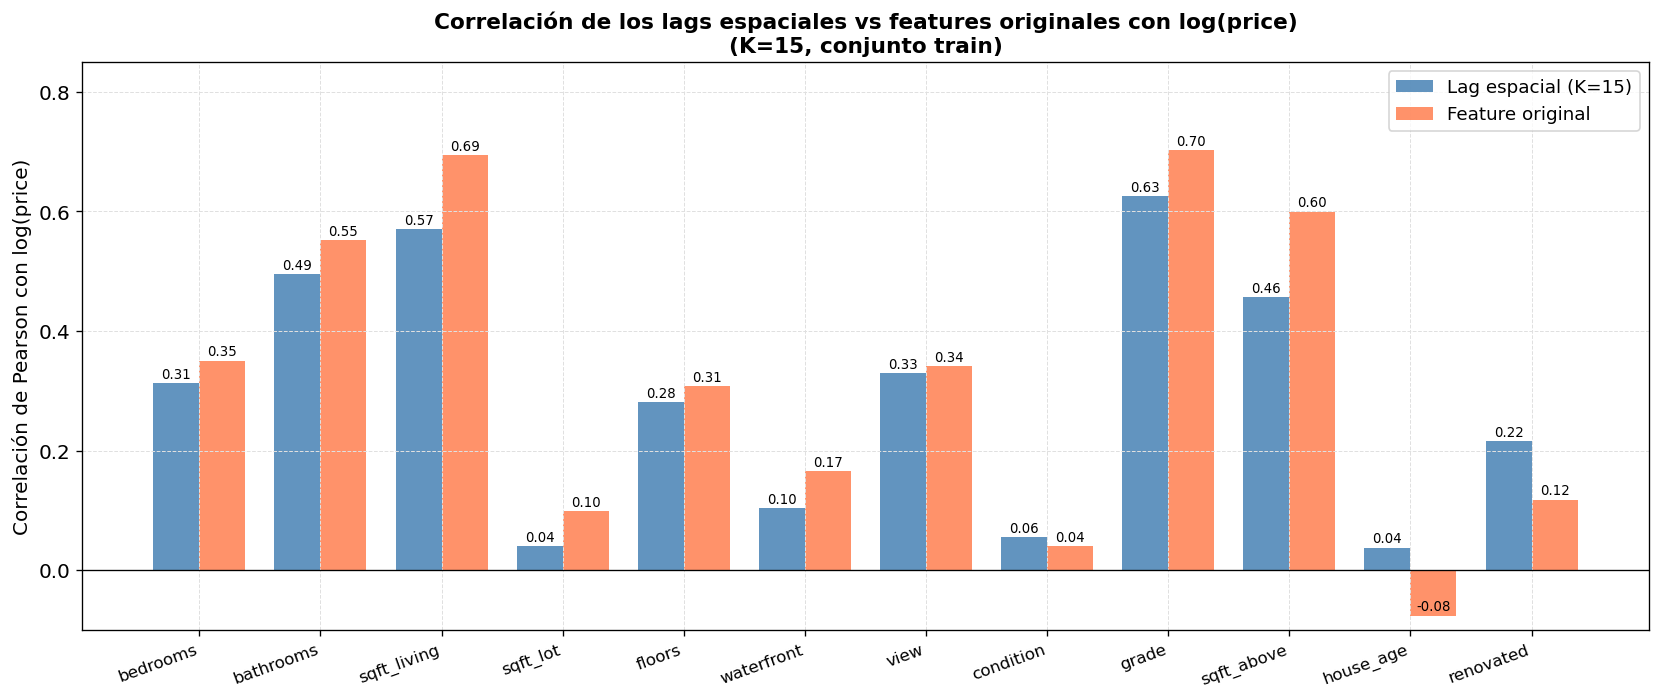

In [8]:
# Figura 1: Correlación de cada lag con log_price (barra horizontal)
lag_corrs  = {col: df_train_spatial[col].corr(y_train) for col in lag_cols}
orig_map   = {f'lag_{f}_k15': f for f in LAG_FEATURES}
orig_corrs = {col: X_train[orig_map[col]].corr(y_train) for col in lag_cols if orig_map[col] in X_train.columns}

labels    = [c.replace('lag_', '').replace('_k15', '') for c in lag_cols]
lag_vals  = [lag_corrs[c] for c in lag_cols]
orig_vals = [orig_corrs.get(c, 0) for c in lag_cols]

x     = np.arange(len(lag_cols))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, lag_vals,  width, label=f'Lag espacial (K={K})', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, orig_vals, width, label='Feature original',       color='coral',     alpha=0.85)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10, rotation=20, ha='right')
ax.set_ylabel('Correlación de Pearson con log(price)', fontsize=12)
ax.set_title(f'Correlación de los lags espaciales vs features originales con log(price)\n(K={K}, conjunto train)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylim(-0.1, 0.85)
plt.tight_layout()
plt.savefig(FIGURES + '03_correlaciones_lags.png')
plt.show()


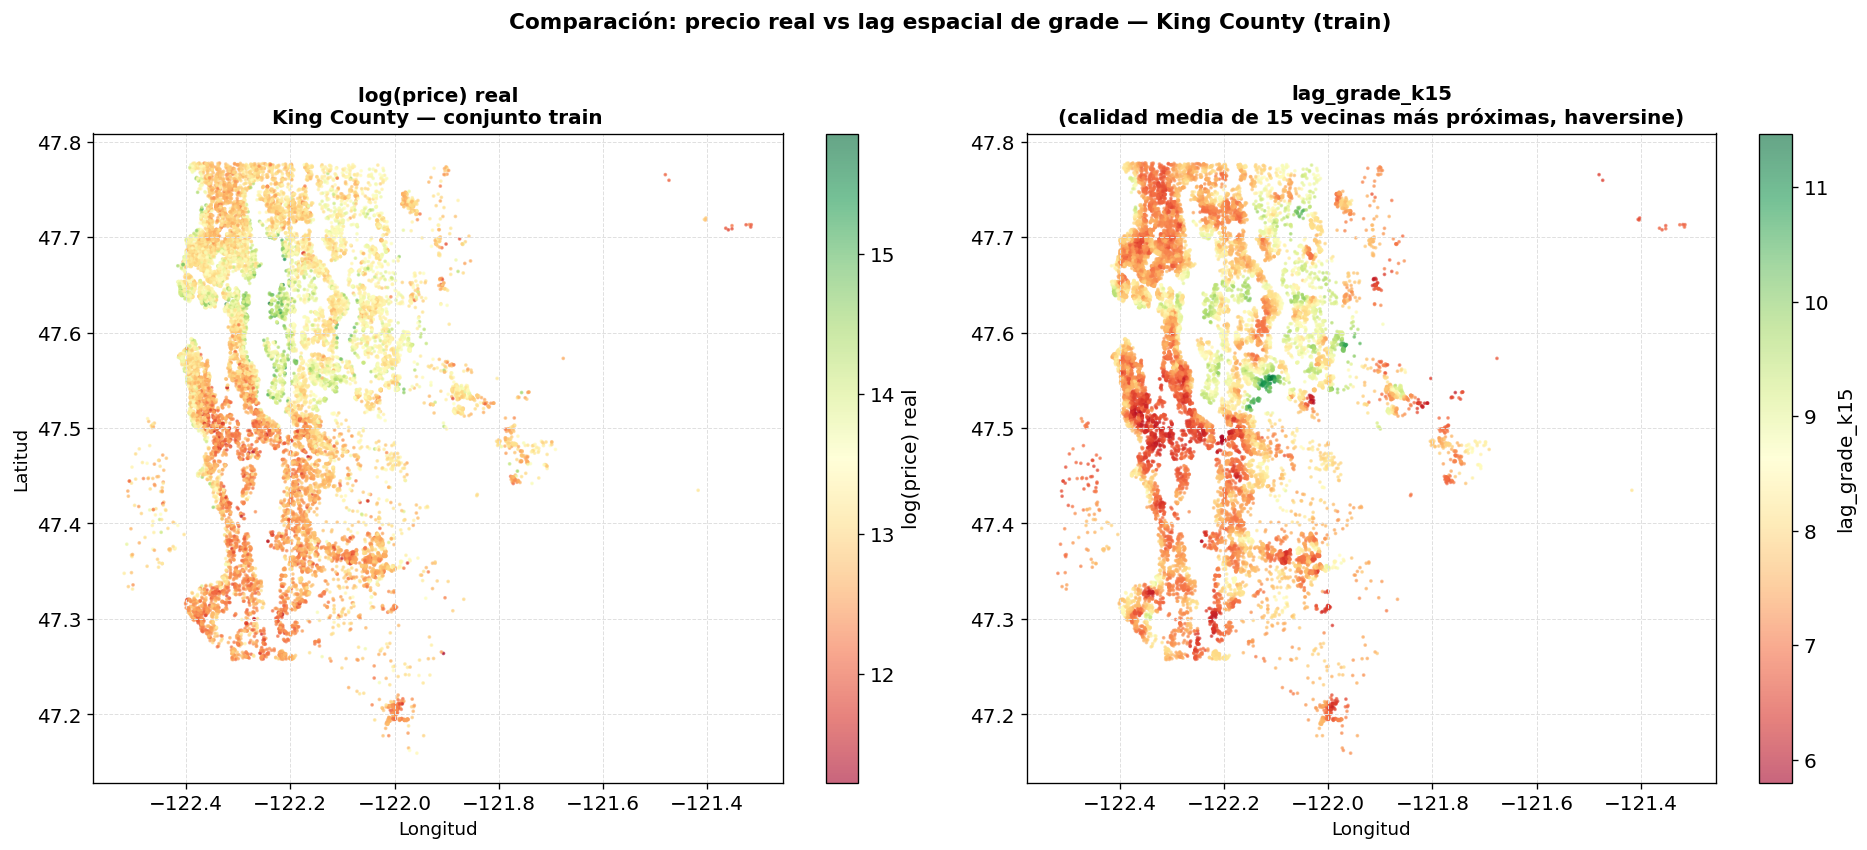

In [9]:
# Figura 2: Mapa geográfico — precio real vs lag_grade_k15
# Si los patrones son similares, el lag de calidad captura la estructura espacial del mercado
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sc1 = axes[0].scatter(
    coords_train[:, 1], coords_train[:, 0],
    c=y_train, cmap='RdYlGn', s=1.5, alpha=0.6
)
plt.colorbar(sc1, ax=axes[0], label='log(price) real')
axes[0].set_title('log(price) real\nKing County — conjunto train', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Longitud', fontsize=11)
axes[0].set_ylabel('Latitud', fontsize=11)

sc2 = axes[1].scatter(
    coords_train[:, 1], coords_train[:, 0],
    c=df_train_spatial['lag_grade_k15'], cmap='RdYlGn', s=1.5, alpha=0.6
)
plt.colorbar(sc2, ax=axes[1], label='lag_grade_k15')
axes[1].set_title(f'lag_grade_k15\n(calidad media de {K} vecinas más próximas, haversine)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Longitud', fontsize=11)

fig.suptitle('Comparación: precio real vs lag espacial de grade — King County (train)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES + '03_mapa_lag_grade.png', bbox_inches='tight')
plt.show()


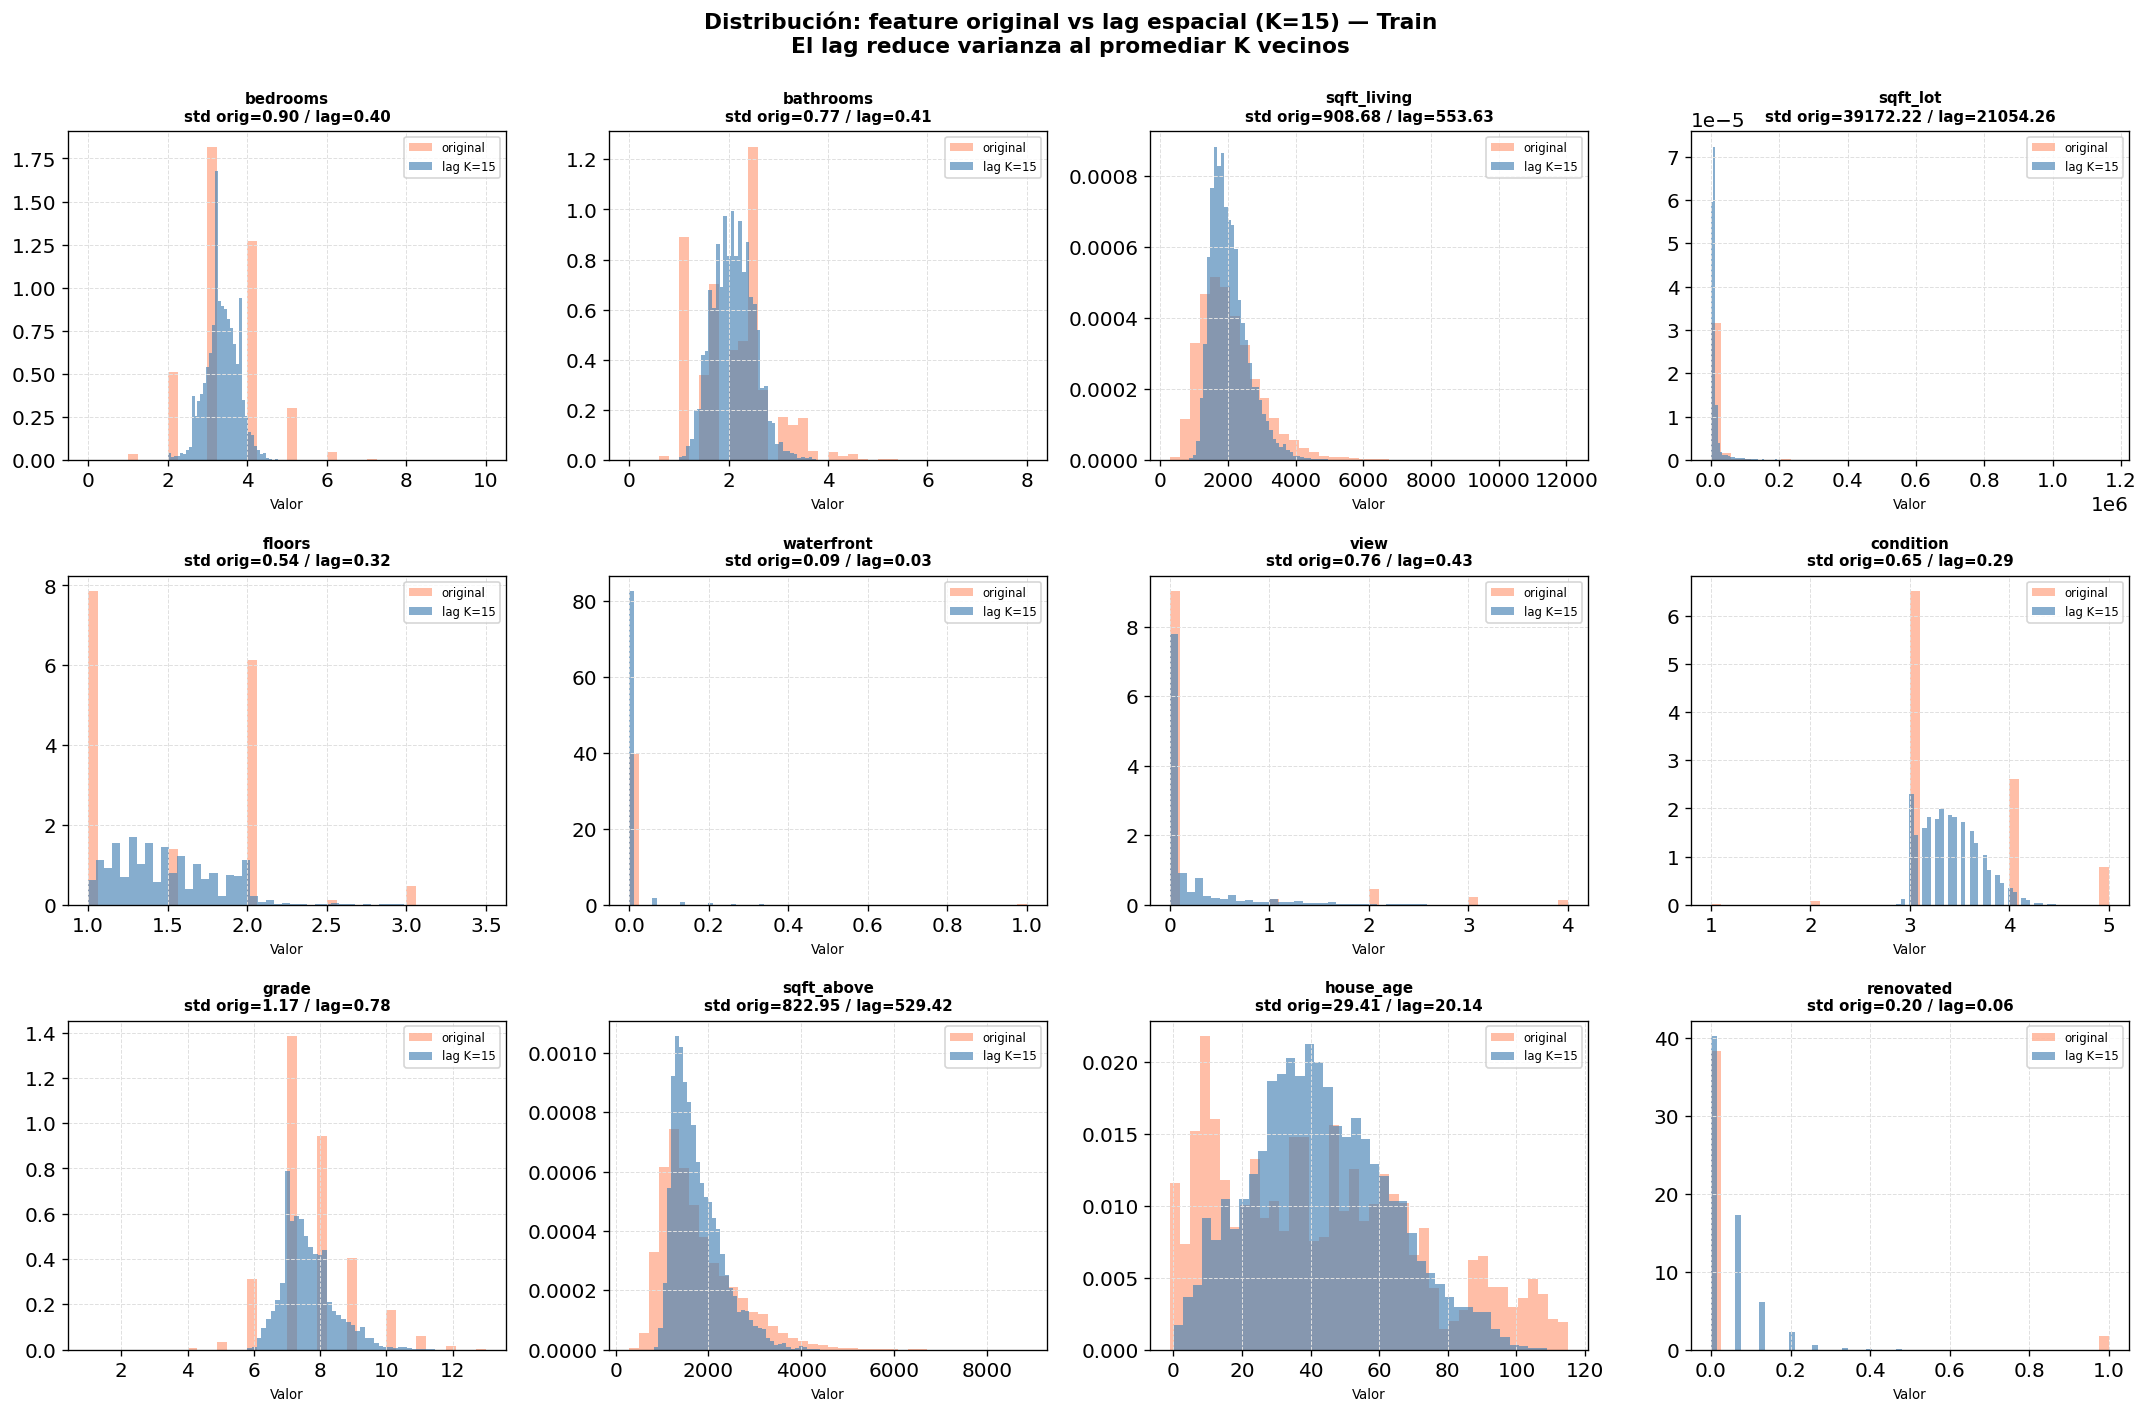

In [10]:
# Figura 3: Distribuciones — feature original vs lag espacial (12 lags, grid 3x4)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, lag_col in enumerate(lag_cols):
    orig_col = lag_col.replace('lag_', '').replace('_k15', '')
    ax = axes[i]
    orig_series = X_train[orig_col]
    std_orig = orig_series.std()
    std_lag  = df_train_spatial[lag_col].std()

    ax.hist(orig_series,                  bins=40, alpha=0.5, color='coral',     density=True, label='original')
    ax.hist(df_train_spatial[lag_col],    bins=40, alpha=0.65, color='steelblue', density=True, label=f'lag K={K}')
    ax.set_title(f'{orig_col}\nstd orig={std_orig:.2f} / lag={std_lag:.2f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=8)
    ax.legend(fontsize=7)

fig.suptitle(f'Distribución: feature original vs lag espacial (K={K}) — Train\n'
             'El lag reduce varianza al promediar K vecinos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES + '03_distribuciones_lags.png')
plt.show()


In [11]:
# Tabla resumen: estadísticas de las 4 nuevas lag features
summary_rows = []
for col in lag_cols:
    orig_name   = col.replace('lag_', '').replace('_k15', '')
    orig_series = X_train.get(orig_name, pd.Series([np.nan]))
    summary_rows.append({
        'Feature lag':             col,
        'Corr. con log_price':     round(df_train_spatial[col].corr(y_train), 4),
        'Media (train)':           round(df_train_spatial[col].mean(), 4),
        'Std (train)':             round(df_train_spatial[col].std(), 4),
        'Std orig':                round(orig_series.std(), 4),
        'Reducción varianza (%)':  round((1 - df_train_spatial[col].std() / orig_series.std()) * 100, 1),
        'NaN (train)':             int(df_train_spatial[col].isnull().sum()),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Feature lag')
print('Resumen de las nuevas features espaciales:')
display(summary_df)

print(f'\nVerificaciones de integridad:')
print(f'  Filas X_train_spatial: {X_train_spatial.shape[0]:,}  (esperado: 17.289)')
print(f'  Filas X_test_spatial:  {X_test_spatial.shape[0]:,}  (esperado: 4.323)')
print(f'  "log_price" en X_train_spatial: {"log_price" in X_train_spatial.columns}  (esperado: False)')
print(f'  NaN en X_train_spatial: {X_train_spatial.isnull().sum().sum()}  (esperado: 0)')
print(f'  NaN en X_test_spatial:  {X_test_spatial.isnull().sum().sum()}  (esperado: 0)')


Resumen de las nuevas features espaciales:


,Corr. con log_price,Media (train),Std (train),Std orig,Reducción varianza (%),NaN (train)
Feature lag,,,,,,
lag_bedrooms_k15,0.3135,3.3622,0.4006,0.9027,55.6,0
lag_bathrooms_k15,0.4946,2.1051,0.4095,0.7681,46.7,0
lag_sqft_living_k15,0.5701,2050.6996,553.6347,908.6844,39.1,0
lag_sqft_lot_k15,0.0401,13358.7116,21054.2577,39172.2184,46.3,0
lag_floors_k15,0.2806,1.4990,0.3192,0.5432,41.2,0
lag_waterfront_k15,0.1038,0.0049,0.0299,0.0854,65.0,0
lag_view_k15,0.3296,0.2085,0.4261,0.7612,44.0,0
lag_condition_k15,0.0554,3.4093,0.2916,0.6511,55.2,0
lag_grade_k15,0.6254,7.6326,0.7779,1.1708,33.6,0



Verificaciones de integridad:
  Filas X_train_spatial: 17,289  (esperado: 17.289)
  Filas X_test_spatial:  4,323  (esperado: 4.323)
  "log_price" en X_train_spatial: False  (esperado: False)
  NaN en X_train_spatial: 0  (esperado: 0)
  NaN en X_test_spatial:  0  (esperado: 0)


In [12]:
# Verificaciones finales de integridad del pipeline
print("Pipeline notebook 03 completado correctamente.")
print(f'  X_train_spatial: {X_train_spatial.shape}')
print(f'  X_test_spatial:  {X_test_spatial.shape}')
print(f'  Lag features generadas: {lag_cols}')


Pipeline notebook 03 completado correctamente.
  X_train_spatial: (17289, 30)
  X_test_spatial:  (4323, 30)
  Lag features generadas: ['lag_bedrooms_k15', 'lag_bathrooms_k15', 'lag_sqft_living_k15', 'lag_sqft_lot_k15', 'lag_floors_k15', 'lag_waterfront_k15', 'lag_view_k15', 'lag_condition_k15', 'lag_grade_k15', 'lag_sqft_above_k15', 'lag_house_age_k15', 'lag_renovated_k15']


## 7. Conclusiones y próximos pasos

### ¿Qué hemos conseguido?

1. **12 nuevas features espaciales** calculadas con KNN (K=15, distancia haversine), sin data leakage:
   - `lag_bedrooms_k15`, `lag_bathrooms_k15`, `lag_sqft_living_k15`, `lag_sqft_lot_k15`
   - `lag_floors_k15`, `lag_waterfront_k15`, `lag_view_k15`, `lag_condition_k15`
   - `lag_grade_k15`, `lag_sqft_above_k15`, `lag_house_age_k15`, `lag_renovated_k15`

2. **El dataset pasa de 18 a 30 columnas**, enriquecido con información del contexto geográfico.

3. **Simetría metodológica:** ningún modelo incluye `lag_log_price` (lag de la variable dependiente).

### Nota metodológica: qué usa cada modelo

| Modelo | Features espaciales |
|---|---|
| **Random Forest / XGBoost** | Los 12 lags completos (`X_train_spatial.csv`) |
| **Modelo SLX** | Subconjunto seleccionado por LASSO (`X_train_slx.csv`) para evitar multicolinealidad |

Los modelos ML (árboles) son robustos a features redundantes — si un lag no aporta, simplemente no se usa.
El SLX (OLS) necesita LASSO previo porque la multicolinealidad infla errores estándar e invalida los tests.

### Próximos pasos

- **`03b_lasso_selection.ipynb`** — LASSO sobre las 30 features para seleccionar las de SLX
- **`04_random_forest.ipynb`** — Random Forest con `X_train_spatial.csv` (30 features)
- **`05_xgboost.ipynb`** — XGBoost con `X_train_spatial.csv` (30 features)
